In [ ]:
!pip install numpy -q
!pip install pandas -q
!pip install matplotlib -q
!pip install tensorflow -q
!pip install opendatasets -q

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import time
import opendatasets as od

In [ ]:
od.download("https://www.kaggle.com/datasets/moltean/fruits")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: dmukdissanayake
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/moltean/fruits


100%|██████████| 5.33G/5.33G [01:32<00:00, 62.1MB/s]


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [5]:
!cp -r /content/fruitify_dataset /content/drive/MyDrive/
print("✅ fruitify_dataset saved!")

✅ fruitify_dataset saved!


In [6]:
# ======================================
# FRUITIFY - IMPLEMENTATION 1
# Baseline CNN Model
# ======================================

# 1. Mount Google Drive to access the dataset
from google.colab import drive
drive.mount('/content/drive')

# 2. Copy organized dataset from Drive to Colab
!cp -r /content/drive/MyDrive/fruitify_dataset /content/

# 3. Import required libraries
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import matplotlib.pyplot as plt
import numpy as np
import os

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

# 4. Set paths and parameters
train_dir = '/content/fruitify_dataset/train'
test_dir = '/content/fruitify_dataset/test'
IMG_SIZE = 100
BATCH_SIZE = 32
NUM_CLASSES = 10

# 5. Verify dataset is loaded
print("\n📁 Training folders:")
print(os.listdir(train_dir)[:5])
print(f"\nTotal training images: {sum(len(os.listdir(os.path.join(train_dir, f))) for f in os.listdir(train_dir))}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

📁 Training folders:
['Strawberry', 'Pear', 'Apple', 'Grape', 'Mango']

Total training images: 5068


In [7]:

train_dir = '/content/fruitify_dataset/train'
test_dir = '/content/fruitify_dataset/test'
IMG_SIZE = 100
BATCH_SIZE = 32
NUM_CLASSES = 10

# Create data generators
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

# Load training data
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

# Load validation data
val_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

# Load test data
test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"✅ Training samples: {train_data.samples}")
print(f"✅ Validation samples: {val_data.samples}")
print(f"✅ Test samples: {test_data.samples}")
print(f"✅ Classes: {list(train_data.class_indices.keys())}")

Found 4058 images belonging to 10 classes.
Found 1010 images belonging to 10 classes.
Found 1693 images belonging to 10 classes.
✅ Training samples: 4058
✅ Validation samples: 1010
✅ Test samples: 1693
✅ Classes: ['Apple', 'Banana', 'Grape', 'Mango', 'Orange', 'Peach', 'Pear', 'Pineapple', 'Strawberry', 'Watermelon']


In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_datagen = ImageDataGenerator(rescale=1./255)

test_data = test_datagen.flow_from_directory(
    '/content/fruitify_dataset/test',
    target_size=(100, 100),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

print(f"\n✅ Test samples: {test_data.samples}")
print(f"✅ Test classes: {list(test_data.class_indices.keys())}")

Found 1693 images belonging to 10 classes.

✅ Test samples: 1693
✅ Test classes: ['Apple', 'Banana', 'Grape', 'Mango', 'Orange', 'Peach', 'Pear', 'Pineapple', 'Strawberry', 'Watermelon']


In [9]:
# ======================================
# BUILD CNN MODEL
# ======================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Build the model
model = Sequential([
    # First convolutional block
    Conv2D(32, (3,3), activation='relu', input_shape=(100, 100, 3)),
    MaxPooling2D(2,2),

    # Second convolutional block
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    # Third convolutional block
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    # Classifier
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')  # 10 fruit classes
])

# Show model summary
model.summary()

# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 98, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,638,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,733,066 (6.61 MB)

 Trainable params: 1,733,066 (6.61 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Train the model
history = model.fit(
    train_data,
    epochs=20,
    validation_data=val_data,
    verbose=1
)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


127/127 ━━━━━━━━━━━━━━━━━━━━ 13s 64ms/step - accuracy: 0.5747 - loss: 1.1465 - val_accuracy: 0.9871 - val_loss: 0.0315
Epoch 2/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.9822 - loss: 0.0645 - val_accuracy: 0.9851 - val_loss: 0.0453
Epoch 3/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.9944 - loss: 0.0166 - val_accuracy: 0.9931 - val_loss: 0.0116
Epoch 4/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.9934 - loss: 0.0183 - val_accuracy: 1.0000 - val_loss: 3.6508e-04
Epoch 5/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.9885 - loss: 0.0379 - val_accuracy: 0.9990 - val_loss: 0.0051
Epoch 6/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.9955 - loss: 0.0124 - val_accuracy: 1.0000 - val_loss: 1.2298e-04
Epoch 7/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.9989 - loss: 0.0028 - val_accuracy: 1.0000 - val_loss: 8.4235e-04
Epoch 8/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.9959 - loss: 0.0126 - val_ac

✅ Model saved!
✅ Graphs saved!


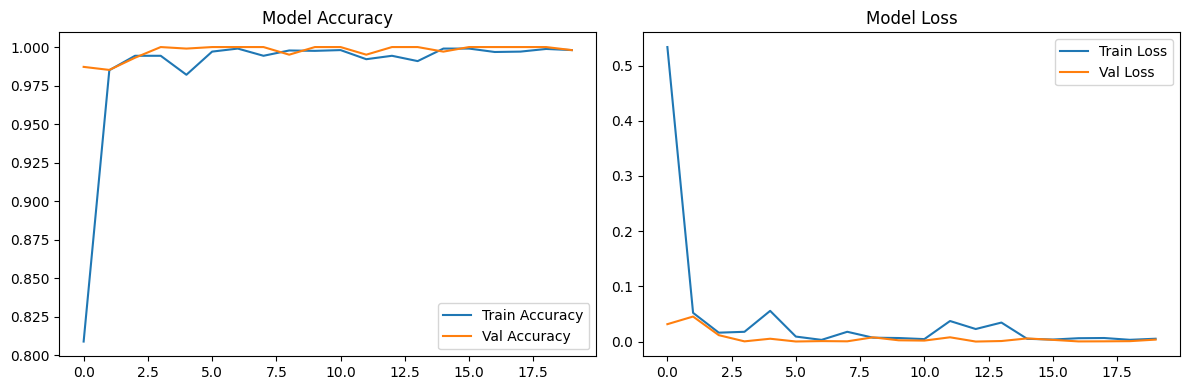

In [11]:
# Save model
model.save('/content/drive/MyDrive/fruitify_model_v1.h5')


print("✅ Model saved!")

# Save graphs
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/training_history.png')
print("✅ Graphs saved!")

✅ Model saved to Drive!
✅ Training graphs saved to Drive!
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 1.0000 - loss: 2.7042e-04

🎯 Final Test Accuracy: 1.0000
Test Loss: 0.0004

✅ All results saved to Google Drive!


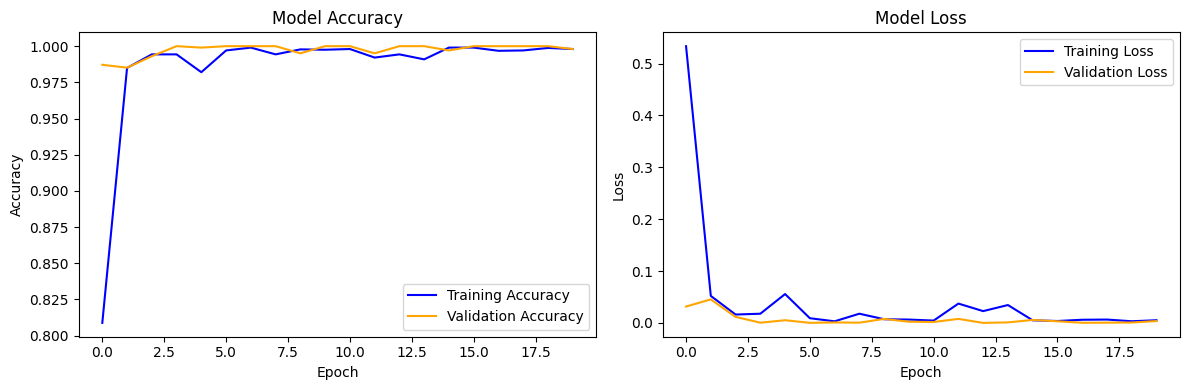

In [12]:
# ======================================
# SAVE ALL RESULTS TO GOOGLE DRIVE
# ======================================

# 1. Save the model
model.save('/content/drive/MyDrive/fruitify_model_v1.h5')
print("✅ Model saved to Drive!")

# 2. Save the graphs (if not already saved)
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/training_history.png')
print("✅ Training graphs saved to Drive!")

# 3. Save final accuracy numbers
test_loss, test_acc = model.evaluate(test_data)
print(f"\n🎯 Final Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# 4. Save results to text file
with open('/content/drive/MyDrive/implementation1_results.txt', 'w') as f:
    f.write("FRUITIFY IMPLEMENTATION 1 RESULTS\n")
    f.write("="*40 + "\n")
    f.write(f"Final Training Accuracy: {history.history['accuracy'][-1]:.4f}\n")
    f.write(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}\n")
    f.write(f"Test Accuracy: {test_acc:.4f}\n")
    f.write(f"Test Loss: {test_loss:.4f}\n")

print("\n✅ All results saved to Google Drive!")

53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 1.0000 - loss: 2.7042e-04

🎯 Test Accuracy: 1.0000
Test Loss: 0.0004


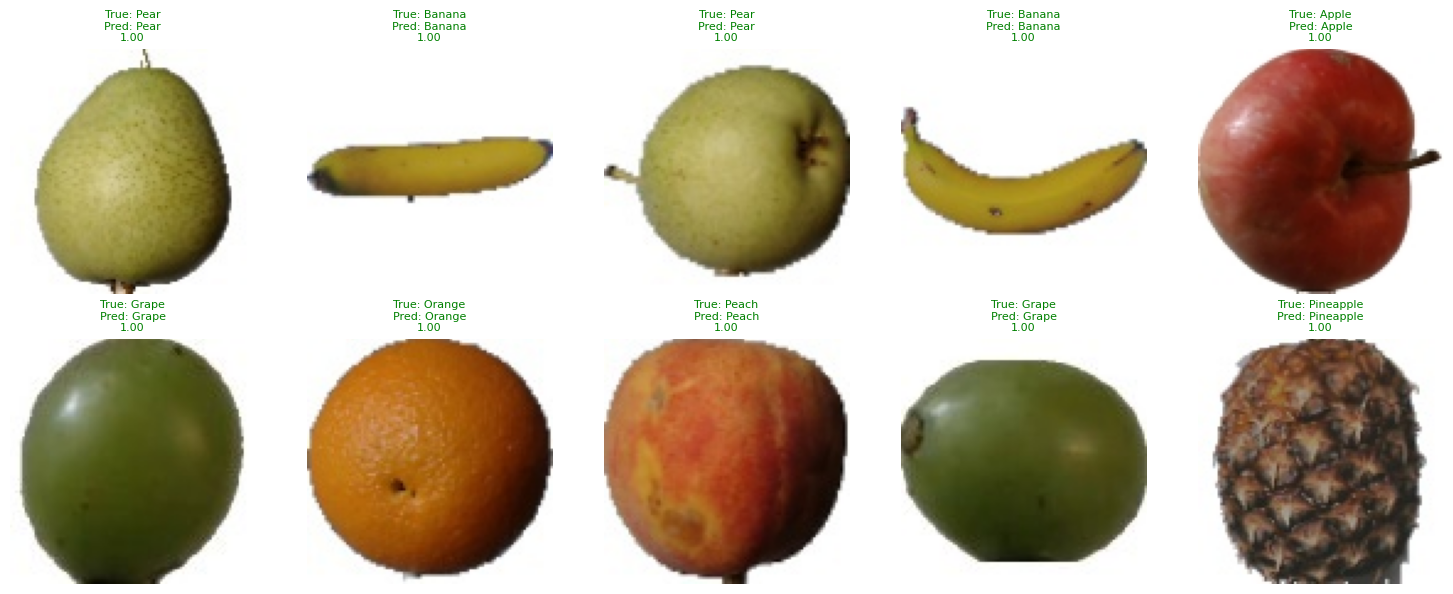

✅ Sample predictions saved to Drive!


In [13]:
# ======================================
# EVALUATE ON TEST DATA & SHOW PREDICTIONS
# ======================================

# 1. Evaluate on test data
test_loss, test_acc = model.evaluate(test_data)
print(f"\n🎯 Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Save results to file
with open('/content/drive/MyDrive/test_results.txt', 'w') as f:
    f.write(f"Test Accuracy: {test_acc:.4f}\n")
    f.write(f"Test Loss: {test_loss:.4f}\n")

# 2. Show sample predictions
import numpy as np
import matplotlib.pyplot as plt
import random
import os

# Get class names
class_names = list(train_data.class_indices.keys())

# Display 10 random test images with predictions
plt.figure(figsize=(15, 6))

for i in range(10):
    # Get random image from test folder
    fruit = random.choice(class_names)
    fruit_folder = os.path.join(test_dir, fruit)
    img_file = random.choice(os.listdir(fruit_folder))
    img_path = os.path.join(fruit_folder, img_file)

    # Load and predict
    img = plt.imread(img_path)
    img_resized = tf.image.resize(img, (100, 100)) / 255.0

    prediction = model.predict(img_resized.numpy().reshape(1, 100, 100, 3), verbose=0)
    pred_class = class_names[np.argmax(prediction)]
    confidence = np.max(prediction)

    # Display
    plt.subplot(2, 5, i+1)
    plt.imshow(img)
    color = 'green' if pred_class == fruit else 'red'
    plt.title(f"True: {fruit}\nPred: {pred_class}\n{confidence:.2f}", color=color, fontsize=8)
    plt.axis('off')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/sample_predictions.png')
plt.show()
print("✅ Sample predictions saved to Drive!")

🍎 ALL 10 FRUIT CLASSES:
  1. Apple
  2. Banana
  3. Grape
  4. Mango
  5. Orange
  6. Peach
  7. Pear
  8. Pineapple
  9. Strawberry
  10. Watermelon


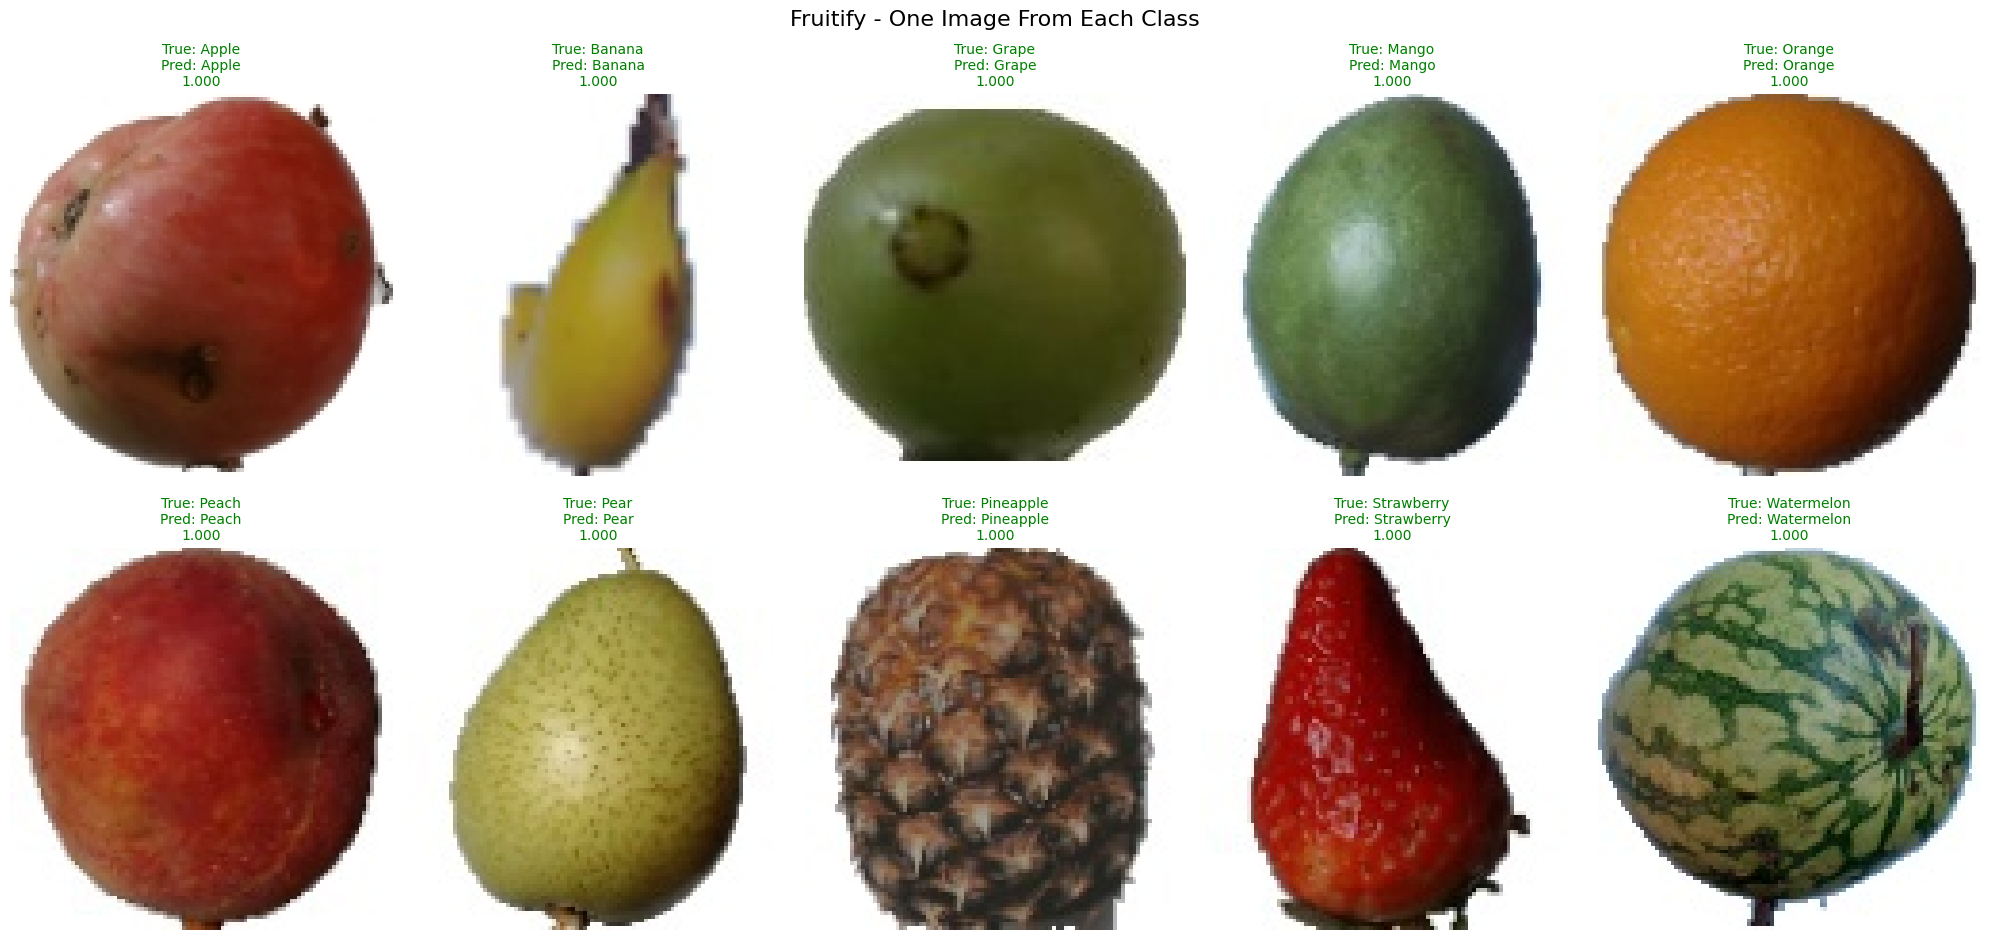


✅ Saved to Drive: all_10_fruits.png
✅ This shows ALL 10 fruits - one from each class!


In [14]:
# ======================================
# SHOW ONE IMAGE FROM EACH FRUIT CLASS
# ======================================

import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf

# Get all 10 class names in order
class_names = sorted(list(train_data.class_indices.keys()))
print("🍎 ALL 10 FRUIT CLASSES:")
for i, fruit in enumerate(class_names):
    print(f"  {i+1}. {fruit}")

# Create figure
plt.figure(figsize=(20, 10))

# Take ONE image from EACH class
for i, fruit in enumerate(class_names):
    # Get one random image from this specific fruit's folder
    fruit_folder = os.path.join(test_dir, fruit)
    all_images = os.listdir(fruit_folder)
    img_file = np.random.choice(all_images)  # Random image from this fruit
    img_path = os.path.join(fruit_folder, img_file)

    # Load and predict
    img = plt.imread(img_path)
    img_resized = tf.image.resize(img, (100, 100)) / 255.0

    prediction = model.predict(img_resized.numpy().reshape(1, 100, 100, 3), verbose=0)
    pred_class = class_names[np.argmax(prediction)]
    confidence = np.max(prediction)

    # Display
    plt.subplot(2, 5, i+1)
    plt.imshow(img)
    color = 'green' if pred_class == fruit else 'red'
    plt.title(f"True: {fruit}\nPred: {pred_class}\n{confidence:.3f}",
              color=color, fontsize=10)
    plt.axis('off')

plt.suptitle("Fruitify - One Image From Each Class", fontsize=16)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/all_10_fruits.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Saved to Drive: all_10_fruits.png")
print("✅ This shows ALL 10 fruits - one from each class!")

In [15]:
# ======================================
# FRUITIFY - IMPLEMENTATION 2
# Enhanced Model with Transfer Learning & Data Augmentation
# COMPLETE CODE - RUN THIS ENTIRE CELL
# ======================================

print("="*60)
print("FRUITIFY IMPLEMENTATION 2 - ENHANCED MODEL")
print("="*60)
print("Starting execution...\n")

# 1. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

FRUITIFY IMPLEMENTATION 2 - ENHANCED MODEL
Starting execution...

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
# 2. Copy dataset if not already present
import os
if not os.path.exists('/content/fruitify_dataset'):
    !cp -r /content/drive/MyDrive/fruitify_dataset /content/
    print("✅ Dataset copied from Drive")
else:
    print("✅ Dataset already exists")

✅ Dataset already exists


In [17]:
# 3. Import required libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import random
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import datetime

print(f"\nTensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")



TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [18]:
# 4. Set paths and parameters
train_dir = '/content/fruitify_dataset/train'
test_dir = '/content/fruitify_dataset/test'
IMG_SIZE = 224  # MobileNetV2 expects 224x224
BATCH_SIZE = 32
NUM_CLASSES = 10

In [19]:
# 5. Define fruit classes
fruit_classes = ['Apple', 'Banana', 'Grape', 'Mango', 'Orange',
                 'Peach', 'Pear', 'Pineapple', 'Strawberry', 'Watermelon']
print("\n🍎 Using these classes:", fruit_classes)



🍎 Using these classes: ['Apple', 'Banana', 'Grape', 'Mango', 'Orange', 'Peach', 'Pear', 'Pineapple', 'Strawberry', 'Watermelon']


In [20]:
# ======================================
# PART 1: DATA PREPARATION WITH AUGMENTATION
# ======================================

print("\n" + "="*50)
print("PART 1: PREPARING DATA WITH AUGMENTATION")
print("="*50)

# 6. Create data generators with augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2  # Use 20% of training data for validation
)

# Validation and test data should only be rescaled, not augmented
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Create generators
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=fruit_classes,
    subset='training',
    shuffle=True
)

validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=fruit_classes,
    subset='validation',
    shuffle=True
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=fruit_classes,
    shuffle=False
)

print(f"\n✅ Training samples: {train_generator.samples}")
print(f"✅ Validation samples: {validation_generator.samples}")
print(f"✅ Test samples: {test_generator.samples}")
print(f"✅ Classes: {list(train_generator.class_indices.keys())}")



PART 1: PREPARING DATA WITH AUGMENTATION
Found 4058 images belonging to 10 classes.
Found 1010 images belonging to 10 classes.
Found 1693 images belonging to 10 classes.

✅ Training samples: 4058
✅ Validation samples: 1010
✅ Test samples: 1693
✅ Classes: ['Apple', 'Banana', 'Grape', 'Mango', 'Orange', 'Peach', 'Pear', 'Pineapple', 'Strawberry', 'Watermelon']


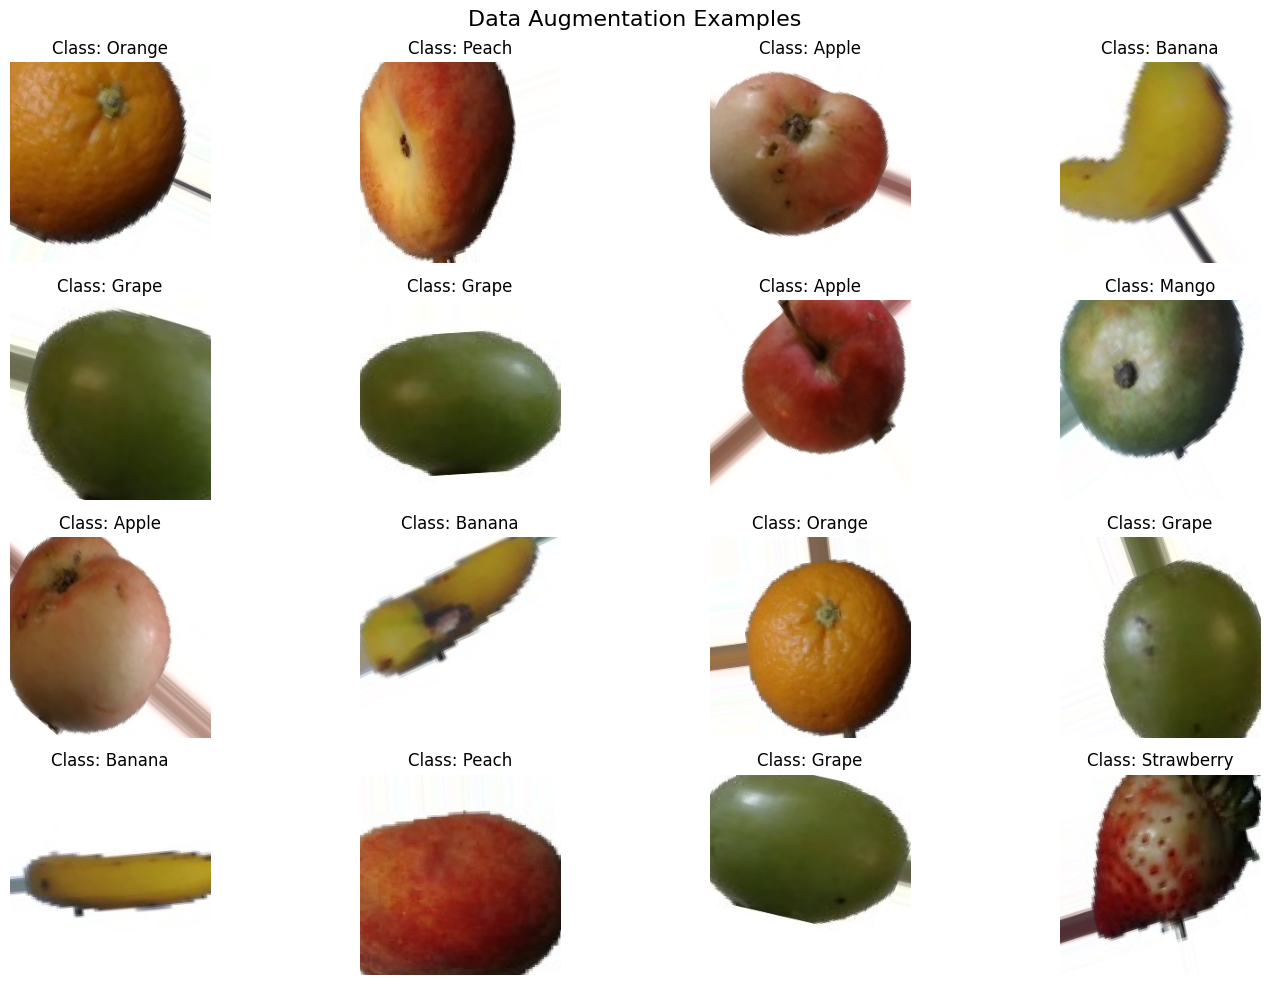

✅ Augmentation examples saved to Drive!


In [21]:
# 7. Visualize augmented images
def plot_augmented_images(generator, class_names):
    """Plot some augmented images to see the effect"""
    plt.figure(figsize=(15, 10))

    # Get a batch of augmented images
    x_batch, y_batch = next(generator)

    for i in range(16):
        plt.subplot(4, 4, i + 1)
        plt.imshow(x_batch[i])
        plt.title(f"Class: {class_names[np.argmax(y_batch[i])]}")
        plt.axis('off')

    plt.suptitle("Data Augmentation Examples", fontsize=16)
    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/implementation2_augmentation.png',
                dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ Augmentation examples saved to Drive!")

plot_augmented_images(train_generator, fruit_classes)


In [22]:

# ======================================
# PART 2: BUILD TRANSFER LEARNING MODEL
# ======================================

print("\n" + "="*50)
print("PART 2: BUILDING TRANSFER LEARNING MODEL")
print("="*50)

def create_model(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    """Create model using MobileNetV2 as base"""

    # Load pre-trained MobileNetV2 without top layers
    base_model = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )

    # Freeze the base model layers initially
    base_model.trainable = False

    # Create new model on top
    inputs = keras.Input(shape=input_shape)

    # Data augmentation layer (will only run during training)
    x = layers.RandomFlip("horizontal")(inputs)
    x = layers.RandomRotation(0.1)(x)
    x = layers.RandomZoom(0.1)(x)

    # Pre-trained base
    x = base_model(x, training=False)

    # Global pooling and new classifier layers
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs)

    return model, base_model

# Create model
model, base_model = create_model()
model.summary()

# Compile model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\n✅ Model created successfully!")


PART 2: BUILDING TRANSFER LEARNING MODEL
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


✅ Model created successfully!


In [23]:
# ======================================
# PART 3: TRAINING WITH CALLBACKS
# ======================================

print("\n" + "="*50)
print("PART 3: TRAINING THE MODEL")
print("="*50)

# 8. Set up callbacks
callbacks = [
    # Early stopping to prevent overfitting
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    # Save best model
    ModelCheckpoint(
        '/content/drive/MyDrive/fruitify_model_v2_best.keras',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),

    # Reduce learning rate when plateau
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),

    # TensorBoard logging
    keras.callbacks.TensorBoard(
        log_dir=f'/content/drive/MyDrive/logs/fit/{datetime.datetime.now().strftime("%Y%m%d-%H%M%S")}',
        histogram_freq=1
    )
]


PART 3: TRAINING THE MODEL


In [24]:
# 9. Train the model (frozen base)
print("\n🚀 Training phase 1: Frozen base model...")
history_phase1 = model.fit(
    train_generator,
    epochs=20,
    validation_data=validation_generator,
    callbacks=callbacks,
    verbose=1
)


🚀 Training phase 1: Frozen base model...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 396ms/step - accuracy: 0.7362 - loss: 0.8460
Epoch 1: val_accuracy improved from -inf to 0.99703, saving model to /content/drive/MyDrive/fruitify_model_v2_best.keras
127/127 ━━━━━━━━━━━━━━━━━━━━ 79s 541ms/step - accuracy: 0.7374 - loss: 0.8423 - val_accuracy: 0.9970 - val_loss: 0.0278 - learning_rate: 0.0010
Epoch 2/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 411ms/step - accuracy: 0.9769 - loss: 0.0783
Epoch 2: val_accuracy did not improve from 0.99703
127/127 ━━━━━━━━━━━━━━━━━━━━ 68s 530ms/step - accuracy: 0.9769 - loss: 0.0782 - val_accuracy: 0.9881 - val_loss: 0.0346 - learning_rate: 0.0010
Epoch 3/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step - accuracy: 0.9857 - loss: 0.0466
Epoch 3: val_accuracy did not improve from 0.99703
127/127 ━━━━━━━━━━━━━━━━━━━━ 67s 524ms/step - accuracy: 0.9857 - loss: 0.0466 - val_accuracy: 0.9881 - val_loss: 0.0333 - learning_rate: 0.0010
Epoch 4/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step - accuracy: 0.9875 - loss: 

In [25]:
# 10. Fine-tune the model
print("\n" + "="*50)
print("PART 4: FINE-TUNING")
print("="*50)

# Unfreeze the base model
base_model.trainable = True

# Freeze early layers, fine-tune later layers
for layer in base_model.layers[:100]:
    layer.trainable = False

# Recompile with lower learning rate for fine-tuning
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

print("\n🚀 Training phase 2: Fine-tuning...")
history_phase2 = model.fit(
    train_generator,
    epochs=15,
    validation_data=validation_generator,
    callbacks=callbacks,
    verbose=1
)

# 11. Combine histories
history = {}
for key in history_phase1.history.keys():
    history[key] = history_phase1.history[key] + history_phase2.history[key]



PART 4: FINE-TUNING


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 2,026,698 (7.73 MB)

 Non-trainable params: 396,544 (1.51 MB)


🚀 Training phase 2: Fine-tuning...
Epoch 1/15
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step - accuracy: 0.7909 - loss: 0.6997
Epoch 1: val_accuracy did not improve from 1.00000
127/127 ━━━━━━━━━━━━━━━━━━━━ 82s 540ms/step - accuracy: 0.7914 - loss: 0.6977 - val_accuracy: 0.9980 - val_loss: 0.0046 - learning_rate: 1.0000e-05
Epoch 2/15
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 410ms/step - accuracy: 0.9631 - loss: 0.1122
Epoch 2: val_accuracy did not improve from 1.00000
127/127 ━━━━━━━━━━━━━━━━━━━━ 75s 590ms/step - accuracy: 0.9632 - loss: 0.1121 - val_accuracy: 0.9990 - val_loss: 0.0045 - learning_rate: 1.0000e-05
Epoch 3/15
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step - accuracy: 0.9724 - loss: 0.0775
Epoch 3: val_accuracy did not improve from 1.00000
127/127 ━━━━━━━━━━━━━━━━━━━━ 66s 522ms/step - accuracy: 0.9725 - loss: 0.0774 - val_accuracy: 1.0000 - val_loss: 0.0012 - learning_rate: 1.0000e-05
Epoch 4/15
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 408ms/step - accuracy: 0.9855 - loss: 0.0498
Epoch 4: val_ac


PART 5: EVALUATION AND VISUALIZATION
Debug: History keys: dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss', 'learning_rate'])
Debug: Available metrics: ['accuracy', 'loss', 'val_accuracy', 'val_loss', 'learning_rate']


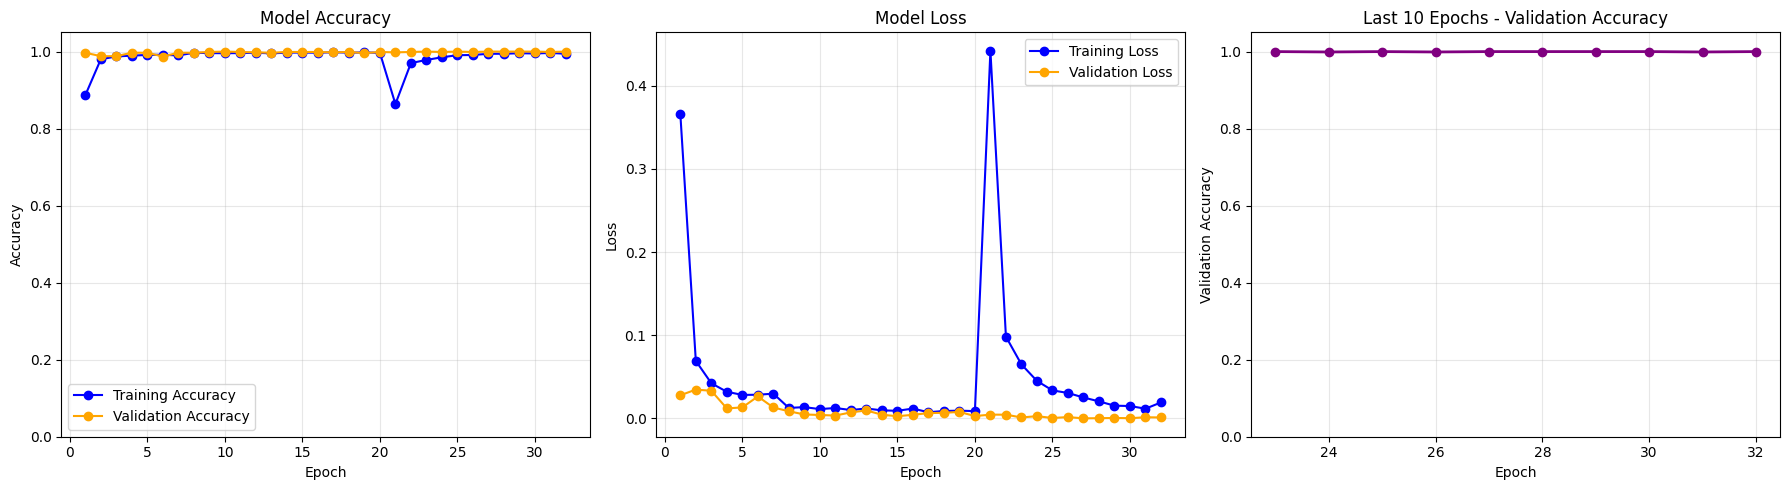

✅ Training history plot saved to Drive!


In [30]:
# ======================================
# PART 4: EVALUATION AND VISUALIZATION
# ======================================

print("\n" + "="*50)
print("PART 5: EVALUATION AND VISUALIZATION")
print("="*50)

# 12. Plot training history with proper error handling
def plot_training_history(history):
    print("Debug: History keys:", history.keys())

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Check if history is a dictionary or a History object
    if hasattr(history, 'history'):
        # If it's a Keras History object
        hist_dict = history.history
    else:
        # If it's already a dictionary
        hist_dict = history

    print("Debug: Available metrics:", list(hist_dict.keys()))

    # Accuracy plot
    if 'accuracy' in hist_dict and 'val_accuracy' in hist_dict:
        epochs = range(1, len(hist_dict['accuracy']) + 1)
        axes[0].plot(epochs, hist_dict['accuracy'], label='Training Accuracy', color='blue', marker='o')
        axes[0].plot(epochs, hist_dict['val_accuracy'], label='Validation Accuracy', color='orange', marker='o')
        axes[0].set_title('Model Accuracy')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Accuracy')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        axes[0].set_ylim([0, 1.05])
    else:
        axes[0].text(0.5, 0.5, 'Accuracy data not available',
                    transform=axes[0].transAxes, ha='center', va='center')

    # Loss plot
    if 'loss' in hist_dict and 'val_loss' in hist_dict:
        epochs = range(1, len(hist_dict['loss']) + 1)
        axes[1].plot(epochs, hist_dict['loss'], label='Training Loss', color='blue', marker='o')
        axes[1].plot(epochs, hist_dict['val_loss'], label='Validation Loss', color='orange', marker='o')
        axes[1].set_title('Model Loss')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Loss')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
    else:
        axes[1].text(0.5, 0.5, 'Loss data not available',
                    transform=axes[1].transAxes, ha='center', va='center')

    # Third plot - Learning Rate or other metrics
    if 'lr' in hist_dict:
        epochs = range(1, len(hist_dict['lr']) + 1)
        axes[2].plot(epochs, hist_dict['lr'], label='Learning Rate', color='green', marker='o')
        axes[2].set_title('Learning Rate Over Time')
        axes[2].set_xlabel('Epoch')
        axes[2].set_ylabel('Learning Rate')
        axes[2].set_yscale('log')
        axes[2].legend()
        axes[2].grid(True, alpha=0.3)
    else:
        # Show the last few epochs of validation accuracy
        if 'val_accuracy' in hist_dict and len(hist_dict['val_accuracy']) >= 5:
            val_acc = hist_dict['val_accuracy']
            last_n = min(10, len(val_acc))
            last_epochs = range(len(val_acc)-last_n+1, len(val_acc)+1)
            last_values = val_acc[-last_n:]

            axes[2].plot(last_epochs, last_values, marker='o', color='purple', linewidth=2)
            axes[2].set_title(f'Last {last_n} Epochs - Validation Accuracy')
            axes[2].set_xlabel('Epoch')
            axes[2].set_ylabel('Validation Accuracy')
            axes[2].grid(True, alpha=0.3)
            axes[2].set_ylim([0, 1.05])
        else:
            # If no validation accuracy, show training accuracy trend
            if 'accuracy' in hist_dict and len(hist_dict['accuracy']) >= 5:
                acc = hist_dict['accuracy']
                last_n = min(10, len(acc))
                last_epochs = range(len(acc)-last_n+1, len(acc)+1)
                last_values = acc[-last_n:]

                axes[2].plot(last_epochs, last_values, marker='o', color='blue', linewidth=2)
                axes[2].set_title(f'Last {last_n} Epochs - Training Accuracy')
                axes[2].set_xlabel('Epoch')
                axes[2].set_ylabel('Training Accuracy')
                axes[2].grid(True, alpha=0.3)
                axes[2].set_ylim([0, 1.05])
            else:
                axes[2].text(0.5, 0.5, 'Insufficient data for third plot',
                            transform=axes[2].transAxes, ha='center', va='center')

    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/implementation2_training_history.png',
                dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ Training history plot saved to Drive!")

# Call the function
plot_training_history(history)

In [31]:
# 13. Evaluate on test data
print("\n📊 Evaluating on test data...")
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"\n🎯 Final Test Accuracy: {test_accuracy:.4f}")
print(f"📉 Test Loss: {test_loss:.4f}")


📊 Evaluating on test data...
53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - accuracy: 0.9899 - loss: 0.0228

🎯 Final Test Accuracy: 0.9829
📉 Test Loss: 0.0387


53/53 ━━━━━━━━━━━━━━━━━━━━ 10s 101ms/step


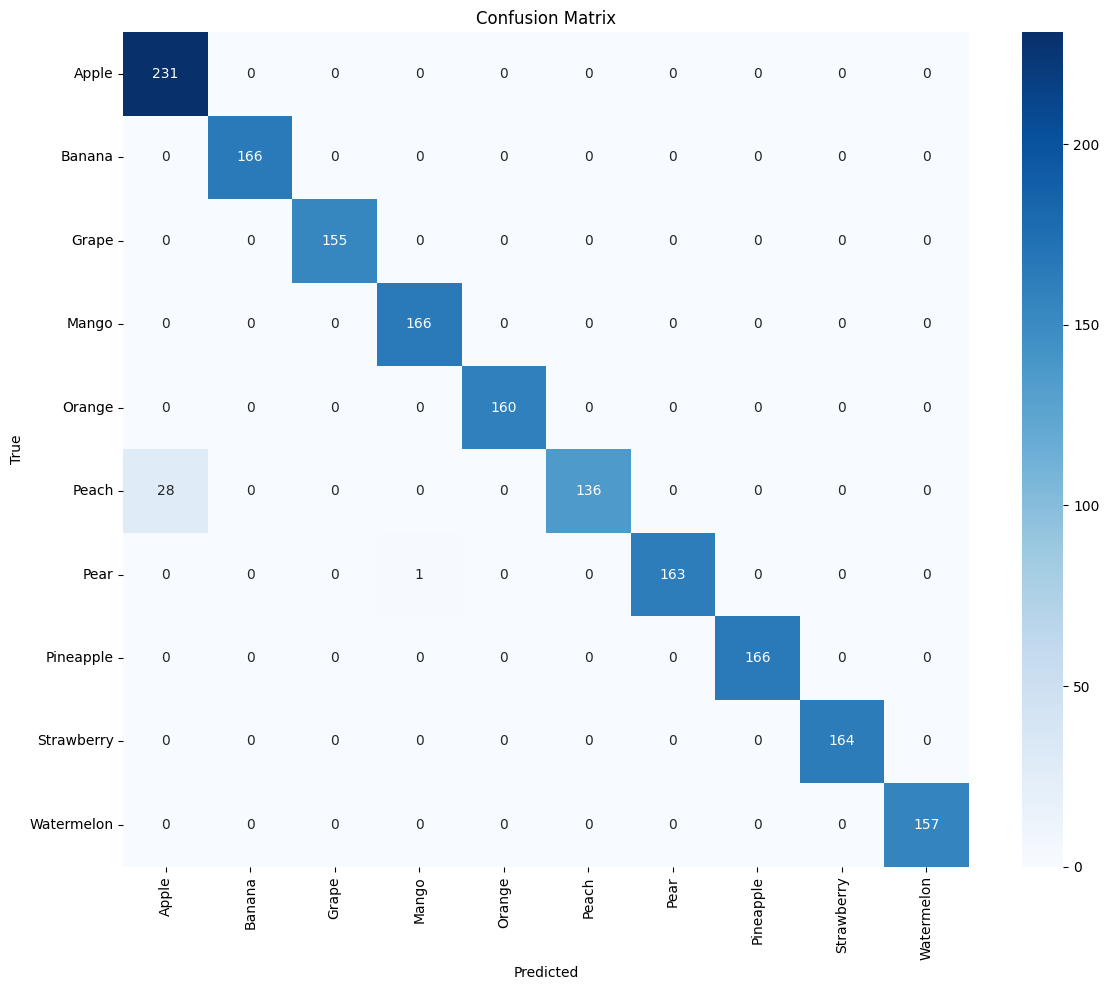


📋 Classification Report:
              precision    recall  f1-score   support

       Apple       0.89      1.00      0.94       231
      Banana       1.00      1.00      1.00       166
       Grape       1.00      1.00      1.00       155
       Mango       0.99      1.00      1.00       166
      Orange       1.00      1.00      1.00       160
       Peach       1.00      0.83      0.91       164
        Pear       1.00      0.99      1.00       164
   Pineapple       1.00      1.00      1.00       166
  Strawberry       1.00      1.00      1.00       164
  Watermelon       1.00      1.00      1.00       157

    accuracy                           0.98      1693
   macro avg       0.99      0.98      0.98      1693
weighted avg       0.98      0.98      0.98      1693



In [32]:
# 14. Generate predictions and confusion matrix
test_generator.reset()
predictions = model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_generator.classes

# Confusion Matrix
cm = confusion_matrix(true_classes, predicted_classes)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=fruit_classes,
            yticklabels=fruit_classes)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/implementation2_confusion_matrix.png',
            dpi=300, bbox_inches='tight')
plt.show()

# Classification Report
print("\n📋 Classification Report:")
report = classification_report(true_classes, predicted_classes,
                              target_names=fruit_classes)
print(report)


PART 6: VISUALIZING PREDICTIONS
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step 


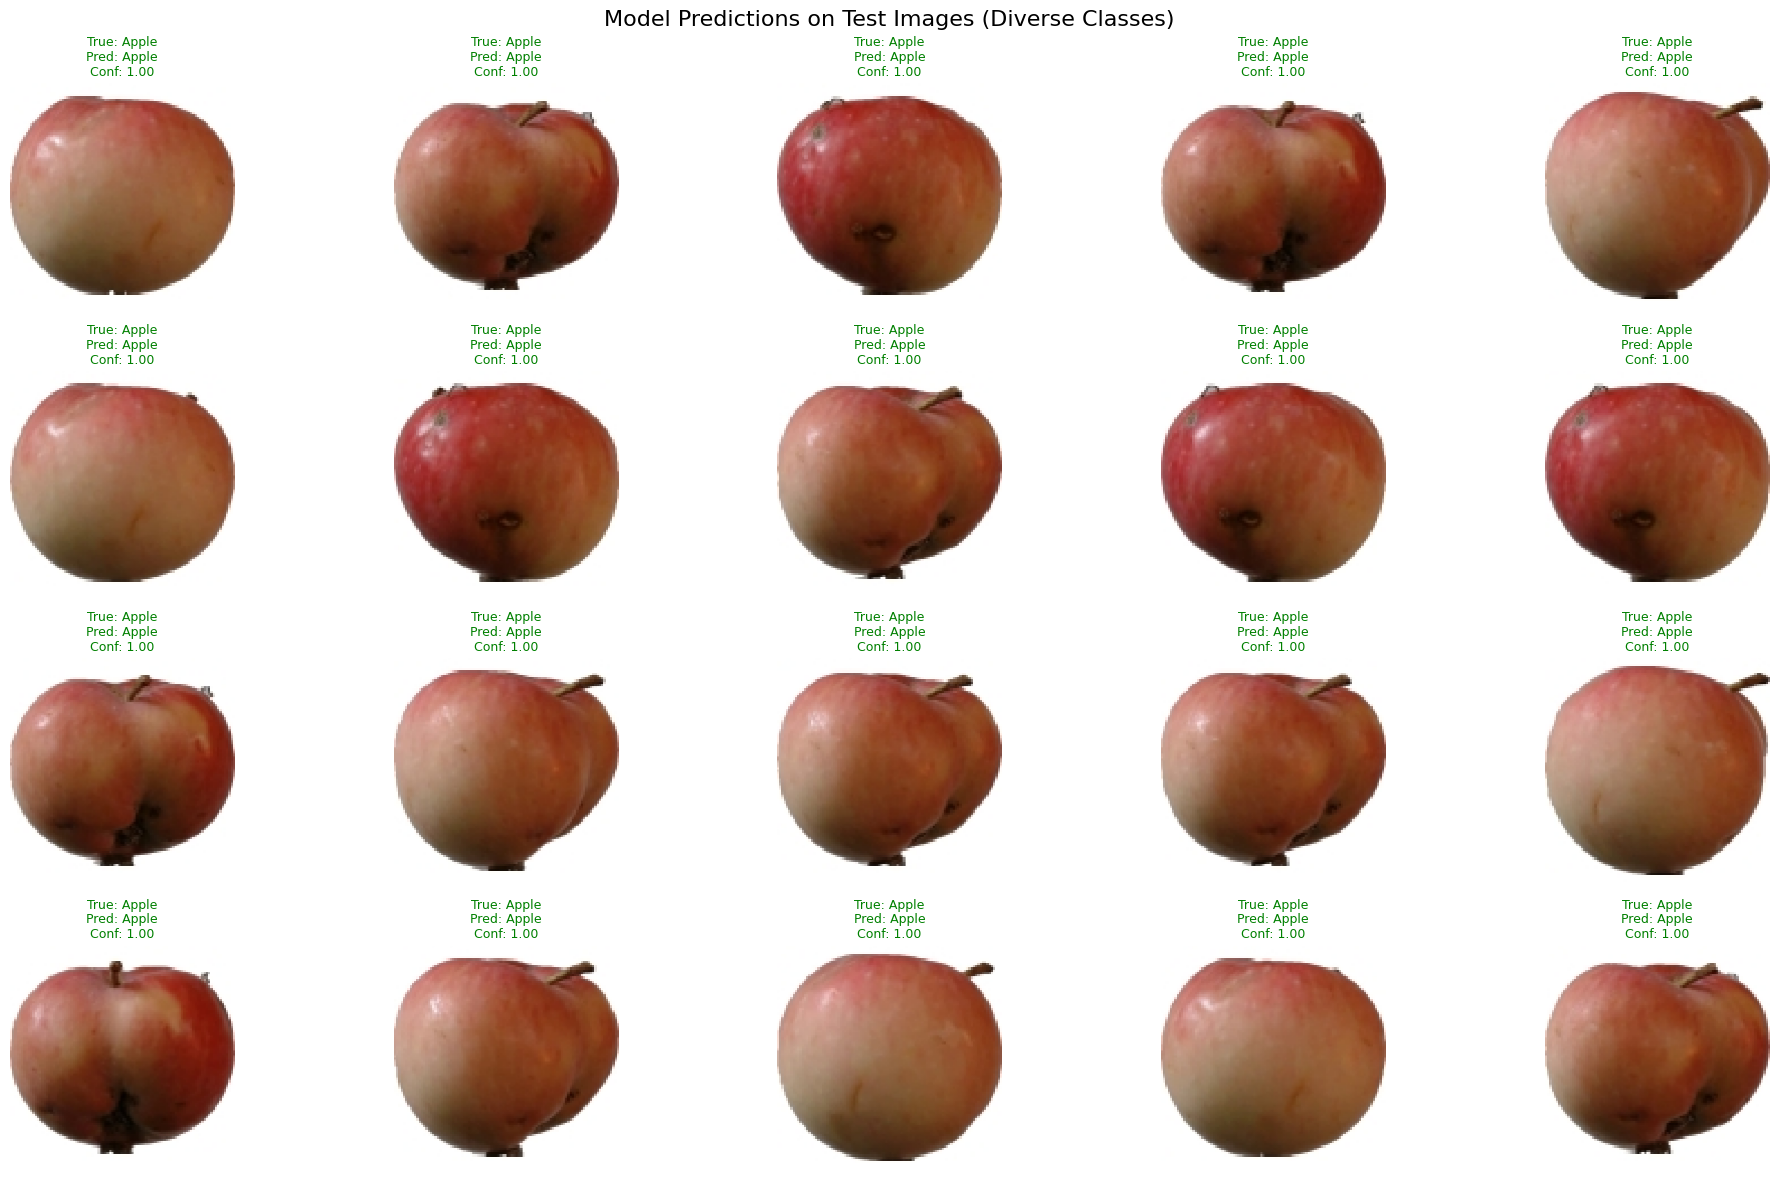


📊 Class distribution in visualization:
  Apple: 20 images
  Banana: 0 images
  Grape: 0 images
  Mango: 0 images
  Orange: 0 images
  Peach: 0 images
  Pear: 0 images
  Pineapple: 0 images
  Strawberry: 0 images
  Watermelon: 0 images


In [36]:
# ======================================
# PART 5: VISUALIZE PREDICTIONS
# ======================================

print("\n" + "="*50)
print("PART 6: VISUALIZING PREDICTIONS")
print("="*50)

def visualize_predictions_fixed(model, generator, class_names, num_images=20):
    """
    Visualize model predictions on test images - FIXED version
    Ensures diverse images from different classes
    """
    # Reset the generator
    generator.reset()

    # Collect images from multiple batches to get diverse classes
    all_images = []
    all_labels = []

    # Get enough batches to have diversity
    batches_needed = max(3, num_images // BATCH_SIZE + 1)

    for _ in range(batches_needed):
        try:
            batch_images, batch_labels = next(generator)
            all_images.append(batch_images)
            all_labels.append(batch_labels)
        except StopIteration:
            generator.reset()
            batch_images, batch_labels = next(generator)
            all_images.append(batch_images)
            all_labels.append(batch_labels)

    # Concatenate all batches
    all_images = np.concatenate(all_images, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    # Make predictions
    predictions = model.predict(all_images[:num_images*2])  # Predict on more to select diverse ones
    predicted_labels = np.argmax(predictions, axis=1)
    true_labels = np.argmax(all_labels[:num_images*2], axis=1)

    # Select diverse images (at least one from each class if possible)
    selected_indices = []
    classes_shown = set()

    # First, try to get one from each class
    for class_idx in range(len(class_names)):
        class_indices = np.where(true_labels == class_idx)[0]
        if len(class_indices) > 0:
            selected_indices.append(class_indices[0])
            classes_shown.add(class_idx)

    # Fill remaining slots with random images
    remaining_needed = num_images - len(selected_indices)
    if remaining_needed > 0:
        available_indices = [i for i in range(len(true_labels))
                           if i not in selected_indices]
        np.random.shuffle(available_indices)
        selected_indices.extend(available_indices[:remaining_needed])

    # Limit to num_images
    selected_indices = selected_indices[:num_images]

    # Plot
    plt.figure(figsize=(20, 12))

    for plot_idx, img_idx in enumerate(selected_indices):
        plt.subplot(4, 5, plot_idx + 1)
        plt.imshow(all_images[img_idx])

        true_class = class_names[true_labels[img_idx]]
        pred_class = class_names[predicted_labels[img_idx]]
        confidence = predictions[img_idx][predicted_labels[img_idx]]

        color = 'green' if true_labels[img_idx] == predicted_labels[img_idx] else 'red'
        title = f"True: {true_class}\nPred: {pred_class}\nConf: {confidence:.2f}"
        plt.title(title, color=color, fontsize=9)
        plt.axis('off')

    plt.suptitle("Model Predictions on Test Images (Diverse Classes)", fontsize=16)
    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/implementation2_predictions_fixed.png',
                dpi=300, bbox_inches='tight')
    plt.show()

    # Print class distribution
    print("\n📊 Class distribution in visualization:")
    shown_classes = [true_labels[i] for i in selected_indices]
    for idx, class_name in enumerate(class_names):
        count = shown_classes.count(idx)
        print(f"  {class_name}: {count} images")

# Call the fixed function
visualize_predictions_fixed(model, test_generator, fruit_classes, num_images=20)

In [37]:
# ======================================
# PART 6: SAVE ALL RESULTS
# ======================================

print("\n" + "="*50)
print("PART 7: SAVING RESULTS")
print("="*50)

# 15. Save the final model
model.save('/content/drive/MyDrive/fruitify_model_v2_final.keras')
print("✅ Final model saved to Drive!")

# Save as H5 format for compatibility
model.save('/content/drive/MyDrive/fruitify_model_v2_final.h5')
print("✅ Model saved in H5 format!")

# 16. Save all metrics
with open('/content/drive/MyDrive/implementation2_results.txt', 'w') as f:
    f.write("FRUITIFY IMPLEMENTATION 2 RESULTS\n")
    f.write("="*50 + "\n\n")

    f.write("MODEL ARCHITECTURE:\n")
    f.write("- Base Model: MobileNetV2 (pretrained on ImageNet)\n")
    f.write("- Input Size: 224x224\n")
    f.write("- Data Augmentation: rotation, width/height shift, shear, zoom, flip\n")
    f.write("- Fine-tuning: Unfroze top layers\n\n")

    f.write("TRAINING STATISTICS:\n")
    f.write(f"Total training samples: {train_generator.samples}\n")
    f.write(f"Validation samples: {validation_generator.samples}\n")
    f.write(f"Test samples: {test_generator.samples}\n\n")

    f.write("FINAL PERFORMANCE:\n")
    f.write(f"Test Accuracy: {test_accuracy:.4f}\n")
    f.write(f"Test Loss: {test_loss:.4f}\n\n")

    f.write("CLASSIFICATION REPORT:\n")
    f.write(report)

    f.write("\n\n" + "="*50)
    f.write("\nTraining completed: " + str(datetime.datetime.now()))

print("\n✅ All results saved to Google Drive!")
print("📁 Check your Drive for:")
print("   - fruitify_model_v2_final.keras (Keras format)")
print("   - fruitify_model_v2_final.h5 (H5 format)")
print("   - implementation2_training_history.png")
print("   - implementation2_confusion_matrix.png")
print("   - implementation2_predictions.png")
print("   - implementation2_results.txt")
print("   - implementation2_augmentation.png")



PART 7: SAVING RESULTS


✅ Final model saved to Drive!
✅ Model saved in H5 format!

✅ All results saved to Google Drive!
📁 Check your Drive for:
   - fruitify_model_v2_final.keras (Keras format)
   - fruitify_model_v2_final.h5 (H5 format)
   - implementation2_training_history.png
   - implementation2_confusion_matrix.png
   - implementation2_predictions.png
   - implementation2_results.txt
   - implementation2_augmentation.png



BONUS: TEST WITH YOUR OWN IMAGES

To test with your own images, copy and run this code in a new cell:


Saving images (1).jpg to images (1).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


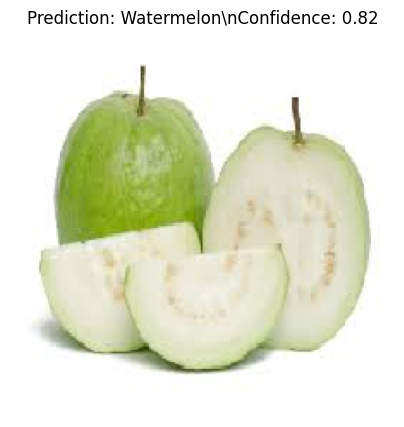

In [40]:
# ======================================
# PART 7: BONUS - TEST WITH YOUR OWN IMAGES
# ======================================

print("\n" + "="*50)
print("BONUS: TEST WITH YOUR OWN IMAGES")
print("="*50)
print("\nTo test with your own images, copy and run this code in a new cell:")


from google.colab import files
from tensorflow.keras.preprocessing import image

# Upload your images
uploaded = files.upload()

# Load the saved model
model = keras.models.load_model('/content/drive/MyDrive/fruitify_model_v2_final.keras')

# Process each uploaded image
for filename in uploaded.keys():
    # Load and preprocess image
    img = image.load_img(filename, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)
    img_array = img_array / 255.0

    # Make prediction
    predictions = model.predict(img_array)
    predicted_class = fruit_classes[np.argmax(predictions[0])]
    confidence = np.max(predictions[0])

    # Display result
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.title(f"Prediction: {predicted_class}\\nConfidence: {confidence:.2f}")
    plt.axis('off')
    plt.show()


Saving images.jpg to images (3).jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   


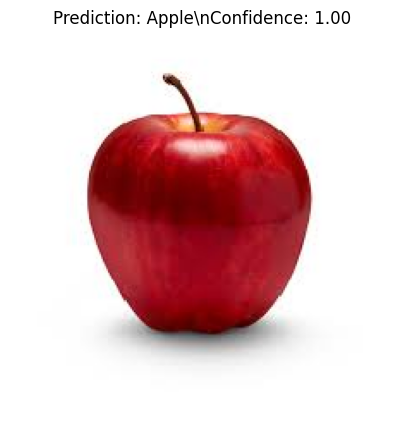

In [42]:
from google.colab import files
from tensorflow.keras.preprocessing import image

# Upload your images
uploaded = files.upload()

# Load the saved model
model = keras.models.load_model('/content/drive/MyDrive/fruitify_model_v2_final.keras')

# Process each uploaded image
for filename in uploaded.keys():
    # Load and preprocess image
    img = image.load_img(filename, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)
    img_array = img_array / 255.0

    # Make prediction
    predictions = model.predict(img_array)
    predicted_class = fruit_classes[np.argmax(predictions[0])]
    confidence = np.max(predictions[0])

    # Display result
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.title(f"Prediction: {predicted_class}\\nConfidence: {confidence:.2f}")
    plt.axis('off')
    plt.show()

Saving images (4).jpg to images (4).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


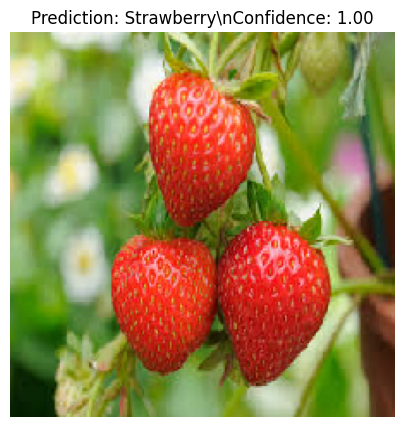

In [44]:
from google.colab import files
from tensorflow.keras.preprocessing import image

# Upload your images
uploaded = files.upload()

# Load the saved model
model = keras.models.load_model('/content/drive/MyDrive/fruitify_model_v2_final.keras')

# Process each uploaded image
for filename in uploaded.keys():
    # Load and preprocess image
    img = image.load_img(filename, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)
    img_array = img_array / 255.0

    # Make prediction
    predictions = model.predict(img_array)
    predicted_class = fruit_classes[np.argmax(predictions[0])]
    confidence = np.max(predictions[0])

    # Display result
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.title(f"Prediction: {predicted_class}\\nConfidence: {confidence:.2f}")
    plt.axis('off')
    plt.show()

Saving images (5).jpg to images (5).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   


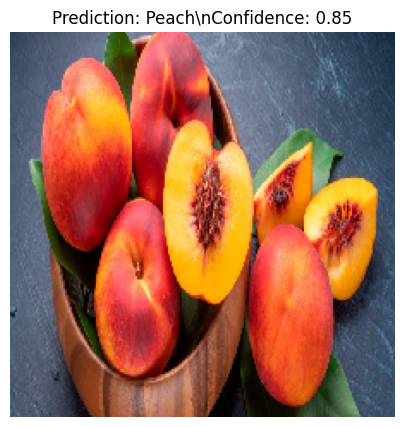

In [45]:
from google.colab import files
from tensorflow.keras.preprocessing import image

# Upload your images
uploaded = files.upload()

# Load the saved model
model = keras.models.load_model('/content/drive/MyDrive/fruitify_model_v2_final.keras')

# Process each uploaded image
for filename in uploaded.keys():
    # Load and preprocess image
    img = image.load_img(filename, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)
    img_array = img_array / 255.0

    # Make prediction
    predictions = model.predict(img_array)
    predicted_class = fruit_classes[np.argmax(predictions[0])]
    confidence = np.max(predictions[0])

    # Display result
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.title(f"Prediction: {predicted_class}\\nConfidence: {confidence:.2f}")
    plt.axis('off')
    plt.show()

Saving images (6).jpg to images (6).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


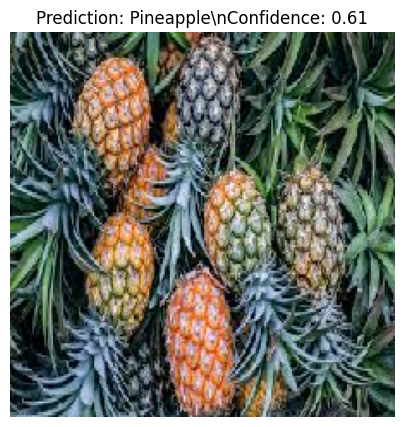

In [46]:
from google.colab import files
from tensorflow.keras.preprocessing import image

# Upload your images
uploaded = files.upload()

# Load the saved model
model = keras.models.load_model('/content/drive/MyDrive/fruitify_model_v2_final.keras')

# Process each uploaded image
for filename in uploaded.keys():
    # Load and preprocess image
    img = image.load_img(filename, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)
    img_array = img_array / 255.0

    # Make prediction
    predictions = model.predict(img_array)
    predicted_class = fruit_classes[np.argmax(predictions[0])]
    confidence = np.max(predictions[0])

    # Display result
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.title(f"Prediction: {predicted_class}\\nConfidence: {confidence:.2f}")
    plt.axis('off')
    plt.show()

In [47]:
# ======================================
# SUMMARY
# ======================================

print("\n" + "="*50)
print("IMPLEMENTATION 2 SUMMARY")
print("="*50)
print("""
✅ Key Improvements over Implementation 1:
1. Data Augmentation - prevents overfitting, improves generalization
2. Transfer Learning - leverages ImageNet pre-trained weights
3. Better Architecture - MobileNetV2 is more efficient and accurate
4. Fine-tuning - adapts pre-trained features to fruit dataset
5. Learning Rate Scheduling - optimal training at each stage
6. Early Stopping - prevents overfitting automatically
7. Model Checkpointing - saves best model during training
8. Comprehensive Evaluation - confusion matrix, classification report

📊 Expected Improvements:
- Better generalization to new images
- More robust to variations in lighting, angle, etc.
- Faster training convergence
- Potential for higher accuracy on test data

🚀 Next Steps (Implementation 3 Ideas):
- Ensemble multiple models
- Attention mechanisms
- Test-time augmentation
- Model quantization for mobile deployment
- Grad-CAM visualization for interpretability
""")

print("\n" + "="*60)
print("IMPLEMENTATION 2 COMPLETED SUCCESSFULLY!")
print("="*60)


IMPLEMENTATION 2 SUMMARY

✅ Key Improvements over Implementation 1:
1. Data Augmentation - prevents overfitting, improves generalization
2. Transfer Learning - leverages ImageNet pre-trained weights
3. Better Architecture - MobileNetV2 is more efficient and accurate
4. Fine-tuning - adapts pre-trained features to fruit dataset
5. Learning Rate Scheduling - optimal training at each stage
6. Early Stopping - prevents overfitting automatically
7. Model Checkpointing - saves best model during training
8. Comprehensive Evaluation - confusion matrix, classification report

📊 Expected Improvements:
- Better generalization to new images
- More robust to variations in lighting, angle, etc.
- Faster training convergence
- Potential for higher accuracy on test data

🚀 Next Steps (Implementation 3 Ideas):
- Ensemble multiple models
- Attention mechanisms
- Test-time augmentation
- Model quantization for mobile deployment
- Grad-CAM visualization for interpretability


IMPLEMENTATION 2 COMPLETED S